**Welcome to Exploratory Data Analysis of Used Bike Prices - EDA Analysis**

In [4]:
import pandas as pd

In [5]:
bikes_df = pd.read_csv("used_bikes_price_analysis_dataset.csv")
bikes_df.head(10)

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio,Age_group
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.00,63500,220.0,Bajaj Avenger Cruise,9,0.086364,"(5, 10]"
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.80,115000,350.0,Royal Enfield Classic,10,0.056571,"(5, 10]"
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.00,300000,250.0,Hyosung GT,14,0.112000,"(10, 20]"
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.50,100000,400.0,Bajaj Dominar,9,0.086250,"(5, 10]"
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.00,197500,330.0,Jawa Perak,6,0.090909,"(5, 10]"
5,KTM Duke 200cc 2012,2012,24561,third owner,Bangalore,35,25.00,63400,200.0,KTM Duke,14,0.125000,"(10, 20]"
6,Bajaj Pulsar 180cc 2016,2016,19718,first owner,Bangalore,65,17.00,55000,180.0,Bajaj Pulsar,10,0.094444,"(5, 10]"
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,2020,40,first owner,Hyderabad,40,20.21,120000,200.0,TVS Apache RTR,6,0.101050,"(5, 10]"
8,KTM Duke 390cc 2018,2018,1350,first owner,Jaipur,25,42.90,198000,390.0,KTM Duke,8,0.110000,"(5, 10]"
9,Yamaha FZ16 150cc 2014,2014,58,first owner,Bangalore,58,13.00,40000,150.0,Yamaha FZ,12,0.086667,"(10, 20]"


In [226]:
# Step 1: Try to get numbers with 'cc'
bikes_df['cc'] = bikes_df['model_name'].str.extract(r'(\d{2,4})\s*cc\b', expand=False)

# Step 2: For rows without 'cc', get first number that is not a year (>1900)
mask = bikes_df['cc'].isna()
bikes_df.loc[mask, 'cc'] = bikes_df.loc[mask, 'model_name'].str.findall(r'\b\d{2,4}\b').apply(
    lambda x: next((int(num) for num in x if int(num) < 1900), None)
)


In [227]:
bikes_df.head(10)

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.00,63500,220.0,Bajaj Avenger Cruise,9,0.086364
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.80,115000,350,Royal Enfield Classic,10,0.056571
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.00,300000,NaN,Hyosung GT,14,0.112000
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.50,100000,400.0,Bajaj Dominar,9,0.086250
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.00,197500,330,Jawa Perak,6,0.090909
5,KTM Duke 200cc 2012,2012,24561,third owner,Bangalore,35,25.00,63400,200,KTM Duke,14,0.125000
6,Bajaj Pulsar 180cc 2016,2016,19718,first owner,Bangalore,65,17.00,55000,180,Bajaj Pulsar,10,0.094444
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,2020,40,first owner,Hyderabad,40,20.21,120000,200.0,TVS Apache RTR,6,0.101050
8,KTM Duke 390cc 2018,2018,1350,first owner,Jaipur,25,42.90,198000,390,KTM Duke,8,0.110000
9,Yamaha FZ16 150cc 2014,2014,58,first owner,Bangalore,58,13.00,40000,150,Yamaha FZ,12,0.086667


In [15]:
bikes_df['cc'].unique()

array([220.0, '350', nan, 400.0, '330', '200', '180', 200.0, '390', '150',
       '410', '125', '110', '220', '223', '500', 250.0, 160.0, 350.0,
       '250', '100', 150.0, '535', '160', 100.0, 180.0, '135', 110.0,
       390.0, '650', '300', 135.0, 883.0, '900', 750.0, 765.0, 821.0,
       310.0, '320', '675', 650.0, 797.0, 300.0, 899.0, '1750', 600.0,
       1000.0, '1745', '1000', '1380', '1200', '865', 800.0, 959.0,
       1200.0, '1300', 1100.0, '1050', 502.0, '1800', '1700', '800',
       '149', 125.0, '750', 97.0, '109'], dtype=object)

In [228]:
# Keep only realistic motorcycle cc values
bikes_df['cc'] = pd.to_numeric(bikes_df['cc'], errors='coerce')  # ensure numeric
bikes_df.loc[(bikes_df['cc'] < 50) | (bikes_df['cc'] > 1200), 'cc'] = pd.NA


In [229]:
# Check unique values after cleaning
print(bikes_df['cc'].unique())

[ 220.  350.   nan  400.  330.  200.  180.  390.  150.  410.  125.  110.
  223.  500.  250.  160.  100.  535.  135.  650.  300.  883.  900.  750.
  765.  821.  310.  320.  675.  797.  899.  600. 1000. 1200.  865.  800.
  959. 1100. 1050.  502.  149.   97.  109.]


In [232]:
# Count NaN values in 'cc' column
nan_count = bikes_df['cc'].isna().sum()
print(f"Number of NaN values in 'cc': {nan_count}")

Number of NaN values in 'cc': 1285


In [233]:
# Filter rows with NaN in 'cc'
nan_bikes = bikes_df[bikes_df['cc'].isna()]

# Show them
print(nan_bikes)

                            model_name  model_year  kms_driven        owner  \
2                  Hyosung GT250R 2012        2012       14795  first owner   
15             Bajaj Pulsar NS200 2018        2018          42  third owner   
30         Bajaj Pulsar NS200 ABS 2020        2020          42  first owner   
31              Bajaj Pulsar 220F 2016        2016       26683  first owner   
32    UM Renegade Commando Mojave 2018        2018        6900  first owner   
...                                ...         ...         ...          ...   
7821          Bajaj Discover 100M 2014        2014          80  first owner   
7828           Bajaj Pulsar AS150 2016        2016        9000  first owner   
7839         Bajaj Discover 125ST 2013        2013       40000  first owner   
7845          Bajaj Discover 100M 2012        2012          80  first owner   
7851       Bajaj Pulsar RS200 ABS 2015        2015          35  first owner   

         location  mileage_kmpl  power_bhp   price 

In [234]:
# Extract cc from model_name
# This regex looks for numbers followed by optional letters (like NS, F, RS)
bikes_df['cc'] = bikes_df['model_name'].str.extract(r'(\d{2,4})(?:\s*[A-Z]{0,3})', expand=False)

In [235]:
bikes_df.head(10)

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.00,63500,220,Bajaj Avenger Cruise,9,0.086364
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.80,115000,350,Royal Enfield Classic,10,0.056571
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.00,300000,250,Hyosung GT,14,0.112000
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.50,100000,400,Bajaj Dominar,9,0.086250
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.00,197500,330,Jawa Perak,6,0.090909
5,KTM Duke 200cc 2012,2012,24561,third owner,Bangalore,35,25.00,63400,200,KTM Duke,14,0.125000
6,Bajaj Pulsar 180cc 2016,2016,19718,first owner,Bangalore,65,17.00,55000,180,Bajaj Pulsar,10,0.094444
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,2020,40,first owner,Hyderabad,40,20.21,120000,200,TVS Apache RTR,6,0.101050
8,KTM Duke 390cc 2018,2018,1350,first owner,Jaipur,25,42.90,198000,390,KTM Duke,8,0.110000
9,Yamaha FZ16 150cc 2014,2014,58,first owner,Bangalore,58,13.00,40000,16,Yamaha FZ,12,0.086667


In [236]:
# Check unique values after cleaning
print(bikes_df['cc'].unique())

['220' '350' '250' '400' '330' '200' '180' '390' '16' '410' '125' '150'
 '2018' '110' '223' '500' '160' '15' '2017' '100' '310' '535' '2019'
 '2021' '25' '295' '12' '2020' '135' '2013' '650' '1000' '2014' '300'
 '302' '883' '900' '750' '765' '821' '320' '675' '797' '800' '1800' '2015'
 '899' '1750' '2016' '600' '2012' '120' '1745' '1380' '1200' '959' '10'
 '1300' '1100' '1050' '502' '1700' '1262' '149' '97']


In [237]:
# Keep only realistic bike cc values (50–1200)
bikes_df['cc'] = pd.to_numeric(bikes_df['cc'], errors='coerce')  # ensure numeric
bikes_df.loc[(bikes_df['cc'] < 50) | (bikes_df['cc'] > 1200), 'cc'] = pd.NA


In [238]:
# Check remaining unique values
print(bikes_df['cc'].unique())
print(f"Remaining NaNs: {bikes_df['cc'].isna().sum()}")

[ 220.  350.  250.  400.  330.  200.  180.  390.   nan  410.  125.  150.
  110.  223.  500.  160.  100.  310.  535.  295.  135.  650. 1000.  300.
  302.  883.  900.  750.  765.  821.  320.  675.  797.  800.  899.  600.
  120. 1200.  959. 1100. 1050.  502.  149.   97.]
Remaining NaNs: 797


In [239]:
print(bikes_df['cc'].unique())

[ 220.  350.  250.  400.  330.  200.  180.  390.   nan  410.  125.  150.
  110.  223.  500.  160.  100.  310.  535.  295.  135.  650. 1000.  300.
  302.  883.  900.  750.  765.  821.  320.  675.  797.  800.  899.  600.
  120. 1200.  959. 1100. 1050.  502.  149.   97.]


In [240]:
# Filter rows where 'cc' is NaN and display model_name
nan_models = bikes_df[bikes_df['cc'].isna()]['model_name']

# Show the model names
print(nan_models)

9                          Yamaha FZ16 150cc 2014
32               UM Renegade Commando Mojave 2018
69                   Yamaha YZF-R15 V3 150cc 2019
70      Hero Splendor ISmart Self Drum Alloy 2017
84               Yamaha YZF-R15 V3 150CC ABS 2019
                          ...                    
7827                    Yamaha YZF-R15 150cc 2014
7838                       Yamaha FZ16 150cc 2015
7840                         Bajaj V15 150cc 2016
7852                    Yamaha YZF-R15 150cc 2011
7855                         Bajaj V15 150cc 2016
Name: model_name, Length: 797, dtype: object


In [241]:
bikes_df.head(10)

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.00,63500,220.0,Bajaj Avenger Cruise,9,0.086364
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.80,115000,350.0,Royal Enfield Classic,10,0.056571
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.00,300000,250.0,Hyosung GT,14,0.112000
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.50,100000,400.0,Bajaj Dominar,9,0.086250
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.00,197500,330.0,Jawa Perak,6,0.090909
5,KTM Duke 200cc 2012,2012,24561,third owner,Bangalore,35,25.00,63400,200.0,KTM Duke,14,0.125000
6,Bajaj Pulsar 180cc 2016,2016,19718,first owner,Bangalore,65,17.00,55000,180.0,Bajaj Pulsar,10,0.094444
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,2020,40,first owner,Hyderabad,40,20.21,120000,200.0,TVS Apache RTR,6,0.101050
8,KTM Duke 390cc 2018,2018,1350,first owner,Jaipur,25,42.90,198000,390.0,KTM Duke,8,0.110000
9,Yamaha FZ16 150cc 2014,2014,58,first owner,Bangalore,58,13.00,40000,NaN,Yamaha FZ,12,0.086667


In [242]:
# lets solve this cc problem : remove year from model_name column, then remaining text, and keep the remaining numbers
#️Create a new df with only model_name
model_df = bikes_df[['model_name']].copy()


In [243]:
model_df.head(10)

,model_name
0,Bajaj Avenger Cruise 220 2017
1,Royal Enfield Classic 350cc 2016
2,Hyosung GT250R 2012
3,Bajaj Dominar 400 ABS 2017
4,Jawa Perak 330cc 2020
5,KTM Duke 200cc 2012
6,Bajaj Pulsar 180cc 2016
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020
8,KTM Duke 390cc 2018
9,Yamaha FZ16 150cc 2014


In [244]:
# Remove the year (assume 4-digit years like 2010-2025)
model_df['model_name_cleaned'] = model_df['model_name'].str.replace(r'\b(19|20)\d{2}\b', '', regex=True)

In [245]:
model_df.head(10)

,model_name,model_name_cleaned
0,Bajaj Avenger Cruise 220 2017,Bajaj Avenger Cruise 220
1,Royal Enfield Classic 350cc 2016,Royal Enfield Classic 350cc
2,Hyosung GT250R 2012,Hyosung GT250R
3,Bajaj Dominar 400 ABS 2017,Bajaj Dominar 400 ABS
4,Jawa Perak 330cc 2020,Jawa Perak 330cc
5,KTM Duke 200cc 2012,KTM Duke 200cc
6,Bajaj Pulsar 180cc 2016,Bajaj Pulsar 180cc
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,TVS Apache RTR 200 4V Dual Channel ABS BS6
8,KTM Duke 390cc 2018,KTM Duke 390cc
9,Yamaha FZ16 150cc 2014,Yamaha FZ16 150cc


In [246]:

# Remove all remaining non-digit text
model_df['model_name_cleaned'] = model_df['model_name_cleaned'].str.replace(r'[^0-9]', ' ', regex=True)



In [247]:
model_df.head(10)

,model_name,model_name_cleaned
0,Bajaj Avenger Cruise 220 2017,220
1,Royal Enfield Classic 350cc 2016,350
2,Hyosung GT250R 2012,250
3,Bajaj Dominar 400 ABS 2017,400
4,Jawa Perak 330cc 2020,330
5,KTM Duke 200cc 2012,200
6,Bajaj Pulsar 180cc 2016,180
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,200 4 6
8,KTM Duke 390cc 2018,390
9,Yamaha FZ16 150cc 2014,16 150


In [248]:
model_df['model_name_cleaned'].unique()

array(['                     220 ', '                      350   ',
       '          250  ', '              400     ', '           330   ',
       '         200   ', '             180   ',
       '               200 4                     6 ', '         390   ',
       '         16 150   ', '                        410   ',
       '                             350   ', '               125   ',
       '                       350   ', '               200 ',
       '                     350   ',
       '                          350       ', '                 150   ',
       '             150   ', '                          350   ',
       '           150   ', '               200     ',
       '             220  ', '                            ',
       '              150   ', '              2 0 150   ',
       '                  125   ', '                    125   ',
       '               110   ', '             220   ',
       '             125   ', '               125       ',
       '

In [249]:
import pandas as pd
import re

def extract_max_number(text):
    # Extract all numbers from the string
    numbers = re.findall(r'\d+', str(text))
    if numbers:
        # Convert to int and return the max
        return max(map(int, numbers))
    return None

# Apply the function to the column
model_df['model_name_cleaned_max'] = model_df['model_name_cleaned'].apply(extract_max_number)



In [250]:
# Check results
model_df.head(10)

,model_name,model_name_cleaned,model_name_cleaned_max
0,Bajaj Avenger Cruise 220 2017,220,220.0
1,Royal Enfield Classic 350cc 2016,350,350.0
2,Hyosung GT250R 2012,250,250.0
3,Bajaj Dominar 400 ABS 2017,400,400.0
4,Jawa Perak 330cc 2020,330,330.0
5,KTM Duke 200cc 2012,200,200.0
6,Bajaj Pulsar 180cc 2016,180,180.0
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,200 4 6,200.0
8,KTM Duke 390cc 2018,390,390.0
9,Yamaha FZ16 150cc 2014,16 150,150.0


In [251]:
model_df['model_name_cleaned_max'].unique()

array([ 220.,  350.,  250.,  400.,  330.,  200.,  180.,  390.,  150.,
        410.,  125.,   nan,  110.,  223.,  500.,  160.,  100.,  310.,
        535.,    2.,  295.,    3.,  135.,   15.,  650., 1000.,  300.,
          6.,  302.,  883.,  900.,  750.,  765.,  821.,  320.,  675.,
        797.,  800., 1800.,  899., 1750.,  600.,  120., 1745., 1380.,
       1200.,  865.,  959.,   10., 1300., 1100., 1050.,  502., 1700.,
       1262.,  149.,    4.,   97.])

In [252]:
# Keep only values >= 50
model_df['model_name_cleaned_max'] = model_df['model_name_cleaned_max'][model_df['model_name_cleaned_max'] >= 50]

In [253]:
model_df['model_name_cleaned_max'].unique()


array([ 220.,  350.,  250.,  400.,  330.,  200.,  180.,  390.,  150.,
        410.,  125.,   nan,  110.,  223.,  500.,  160.,  100.,  310.,
        535.,  295.,  135.,  650., 1000.,  300.,  302.,  883.,  900.,
        750.,  765.,  821.,  320.,  675.,  797.,  800., 1800.,  899.,
       1750.,  600.,  120., 1745., 1380., 1200.,  865.,  959., 1300.,
       1100., 1050.,  502., 1700., 1262.,  149.,   97.])

In [254]:
model_df['model_name_cleaned_max'].unique()

array([ 220.,  350.,  250.,  400.,  330.,  200.,  180.,  390.,  150.,
        410.,  125.,   nan,  110.,  223.,  500.,  160.,  100.,  310.,
        535.,  295.,  135.,  650., 1000.,  300.,  302.,  883.,  900.,
        750.,  765.,  821.,  320.,  675.,  797.,  800., 1800.,  899.,
       1750.,  600.,  120., 1745., 1380., 1200.,  865.,  959., 1300.,
       1100., 1050.,  502., 1700., 1262.,  149.,   97.])

In [255]:
# check for nan
model_df['model_name_cleaned_max'].isna().sum()

np.int64(260)

In [256]:
model_df[model_df['model_name_cleaned_max'].isna()]

,model_name,model_name_cleaned,model_name_cleaned_max
32,UM Renegade Commando Mojave 2018,,NaN
70,Hero Splendor ISmart Self Drum Alloy 2017,,NaN
124,Hero Splendor Plus Special Edition IBS 2019,,NaN
129,Hero Splendor ISmart Self Drum Alloy 2017,,NaN
139,Honda Hornet 2.0 2021,2 0,NaN
...,...,...,...
7303,UM Renegade Commando 2017,,NaN
7489,UM Renegade Commando 2017,,NaN
7552,Hero Splendor Plus i3s 2018,3,NaN
7619,Hero Passion Xpro Disc 2018,,NaN


In [258]:
model_df['model_name_cleaned_max'].unique()

array([ 220.,  350.,  250.,  400.,  330.,  200.,  180.,  390.,  150.,
        410.,  125.,   nan,  110.,  223.,  500.,  160.,  100.,  310.,
        535.,  295.,  135.,  650., 1000.,  300.,  302.,  883.,  900.,
        750.,  765.,  821.,  320.,  675.,  797.,  800., 1800.,  899.,
       1750.,  600.,  120., 1745., 1380., 1200.,  865.,  959., 1300.,
       1100., 1050.,  502., 1700., 1262.,  149.,   97.])

In [259]:
model_df.head(10)

,model_name,model_name_cleaned,model_name_cleaned_max
0,Bajaj Avenger Cruise 220 2017,220,220.0
1,Royal Enfield Classic 350cc 2016,350,350.0
2,Hyosung GT250R 2012,250,250.0
3,Bajaj Dominar 400 ABS 2017,400,400.0
4,Jawa Perak 330cc 2020,330,330.0
5,KTM Duke 200cc 2012,200,200.0
6,Bajaj Pulsar 180cc 2016,180,180.0
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,200 4 6,200.0
8,KTM Duke 390cc 2018,390,390.0
9,Yamaha FZ16 150cc 2014,16 150,150.0


In [260]:
# convert 'model_name_cleaned_max' to int64
model_df['model_name_cleaned_max'] = model_df['model_name_cleaned_max'].fillna(0).astype('int64')

In [261]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   model_name              7857 non-null   object
 1   model_name_cleaned      7857 non-null   object
 2   model_name_cleaned_max  7857 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 184.3+ KB


In [262]:
# rename column nm to 'cc'
model_df = model_df.rename(columns={'model_name_cleaned_max': 'cc'})

In [263]:
model_df.head(50)

,model_name,model_name_cleaned,cc
0,Bajaj Avenger Cruise 220 2017,220,220
1,Royal Enfield Classic 350cc 2016,350,350
2,Hyosung GT250R 2012,250,250
3,Bajaj Dominar 400 ABS 2017,400,400
4,Jawa Perak 330cc 2020,330,330
5,KTM Duke 200cc 2012,200,200
6,Bajaj Pulsar 180cc 2016,180,180
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,200 4 6,200
8,KTM Duke 390cc 2018,390,390
9,Yamaha FZ16 150cc 2014,16 150,150


In [264]:
# replace values in column bikes_df['cc'] with model_df['cc']
bikes_df['cc'] = model_df['cc']

In [265]:
bikes_df.head(50)

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.00,63500,220,Bajaj Avenger Cruise,9,0.086364
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.80,115000,350,Royal Enfield Classic,10,0.056571
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.00,300000,250,Hyosung GT,14,0.112000
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.50,100000,400,Bajaj Dominar,9,0.086250
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.00,197500,330,Jawa Perak,6,0.090909
5,KTM Duke 200cc 2012,2012,24561,third owner,Bangalore,35,25.00,63400,200,KTM Duke,14,0.125000
6,Bajaj Pulsar 180cc 2016,2016,19718,first owner,Bangalore,65,17.00,55000,180,Bajaj Pulsar,10,0.094444
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,2020,40,first owner,Hyderabad,40,20.21,120000,200,TVS Apache RTR,6,0.101050
8,KTM Duke 390cc 2018,2018,1350,first owner,Jaipur,25,42.90,198000,390,KTM Duke,8,0.110000
9,Yamaha FZ16 150cc 2014,2014,58,first owner,Bangalore,58,13.00,40000,150,Yamaha FZ,12,0.086667


In [143]:
bikes_df['brand'] = bikes_df['model_name'].str.extract(r'^([^\d]+)')

In [266]:
bikes_df.head(10)

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.00,63500,220,Bajaj Avenger Cruise,9,0.086364
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.80,115000,350,Royal Enfield Classic,10,0.056571
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.00,300000,250,Hyosung GT,14,0.112000
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.50,100000,400,Bajaj Dominar,9,0.086250
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.00,197500,330,Jawa Perak,6,0.090909
5,KTM Duke 200cc 2012,2012,24561,third owner,Bangalore,35,25.00,63400,200,KTM Duke,14,0.125000
6,Bajaj Pulsar 180cc 2016,2016,19718,first owner,Bangalore,65,17.00,55000,180,Bajaj Pulsar,10,0.094444
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,2020,40,first owner,Hyderabad,40,20.21,120000,200,TVS Apache RTR,6,0.101050
8,KTM Duke 390cc 2018,2018,1350,first owner,Jaipur,25,42.90,198000,390,KTM Duke,8,0.110000
9,Yamaha FZ16 150cc 2014,2014,58,first owner,Bangalore,58,13.00,40000,150,Yamaha FZ,12,0.086667


In [267]:
bikes_df['brand'].unique()

array(['Bajaj Avenger Cruise ', 'Royal Enfield Classic ', 'Hyosung GT',
       'Bajaj Dominar ', 'Jawa Perak ', 'KTM Duke ', 'Bajaj Pulsar ',
       'TVS Apache RTR ', 'Yamaha FZ', 'Royal Enfield Himalayan ',
       'Royal Enfield Bullet Electra ', 'Honda CB Shine ',
       'Royal Enfield Standard ', 'Bajaj Pulsar NS',
       'Royal Enfield Bullet ', 'Royal Enfield Thunderbird ',
       'Honda CB Unicorn ', 'Royal Enfield Electra ',
       'Bajaj Avenger Street ', 'Yamaha SZ-RR ', 'Yamaha FZs ',
       'UM Renegade Commando Mojave ', 'Hero Achiever ', 'Yamaha FZ S V ',
       'Honda CBR ', 'Hero Glamour Disc ', 'Hero Super Splendor ',
       'Bajaj Discover ', 'Hero Ignitor ', 'Hero Karizma R ', 'KTM RC ',
       'Suzuki Gixxer ', 'Honda CB ShineSP ', 'Hero Passion Xpro ',
       'Husqvarna Svartpilen ', 'Royal Enfield Thunderbird X ',
       'Suzuki Gixxer SF ', 'Yamaha YZF-R',
       'Hero Splendor ISmart Self Drum Alloy ', 'Hero Passion Pro ',
       'Yamaha SZ RR V ', 'Bajaj Pulsar

In [149]:
bikes_df.head()

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.0,63500,220,Bajaj Avenger Cruise,9
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.8,115000,350,Royal Enfield Classic,10
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.0,300000,250,Hyosung GT,14
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.5,100000,400,Bajaj Dominar,9
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.0,197500,330,Jawa Perak,6


In [150]:
bikes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model_name    7857 non-null   object 
 1   model_year    7857 non-null   int64  
 2   kms_driven    7857 non-null   int64  
 3   owner         7857 non-null   object 
 4   location      7857 non-null   object 
 5   mileage_kmpl  7857 non-null   int64  
 6   power_bhp     7857 non-null   float64
 7   price         7857 non-null   int64  
 8   cc            7857 non-null   int64  
 9   brand         7857 non-null   object 
 10  age           7857 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 675.3+ KB


In [268]:
# convert from object to int
bikes_df['power_bhp'] = pd.to_numeric(bikes_df['power_bhp'], errors='coerce')
bikes_df['cc'] = pd.to_numeric(bikes_df['cc'], errors='coerce')

In [269]:
#  Power-to-Weight Ratio: For bikes where both power and cc are available, create a ratio feature.
bikes_df.head()

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.0,63500,220,Bajaj Avenger Cruise,9,0.086364
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.8,115000,350,Royal Enfield Classic,10,0.056571
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.0,300000,250,Hyosung GT,14,0.112000
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.5,100000,400,Bajaj Dominar,9,0.086250
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.0,197500,330,Jawa Perak,6,0.090909


In [270]:
bikes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   model_name      7857 non-null   object 
 1   model_year      7857 non-null   int64  
 2   kms_driven      7857 non-null   int64  
 3   owner           7857 non-null   object 
 4   location        7857 non-null   object 
 5   mileage_kmpl    7857 non-null   int64  
 6   power_bhp       7857 non-null   float64
 7   price           7857 non-null   int64  
 8   cc              7857 non-null   int64  
 9   brand           7857 non-null   object 
 10  age             7857 non-null   int64  
 11  power_cc_ratio  7857 non-null   float64
dtypes: float64(2), int64(6), object(4)
memory usage: 736.7+ KB


In [168]:
# lets remove duplicate col
bikes_df = bikes_df.drop(columns=['power_to_cc_ratio'])

In [169]:
bikes_df.head()

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.0,63500,220,Bajaj Avenger Cruise,9,0.086364
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.8,115000,350,Royal Enfield Classic,10,0.056571
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.0,300000,250,Hyosung GT,14,0.112000
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.5,100000,400,Bajaj Dominar,9,0.086250
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.0,197500,330,Jawa Perak,6,0.090909


In [172]:
#save it as fineal for further analysis
bikes_df.to_csv('used_bikes_price_analysis_dataset.csv', index=False)

In [174]:
# conduct EDA on bikes_df
bikes_df.shape

(7857, 12)

In [175]:
bikes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   model_name      7857 non-null   object 
 1   model_year      7857 non-null   int64  
 2   kms_driven      7857 non-null   int64  
 3   owner           7857 non-null   object 
 4   location        7857 non-null   object 
 5   mileage_kmpl    7857 non-null   int64  
 6   power_bhp       7857 non-null   float64
 7   price           7857 non-null   int64  
 8   cc              7857 non-null   int64  
 9   brand           7857 non-null   object 
 10  age             7857 non-null   int64  
 11  power_cc_ratio  7857 non-null   float64
dtypes: float64(2), int64(6), object(4)
memory usage: 736.7+ KB


In [271]:
bikes_df.describe()

C:\Users\Charitha\AppData\Local\Programs\Python\Python310\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,model_year,kms_driven,mileage_kmpl,power_bhp,price,cc,age,power_cc_ratio
count,7857.000000,7857.000000,7857.000000,7857.000000,7.857000e+03,7857.000000,7857.000000,7857.000000
mean,2015.367698,17265.308769,44.308515,20.758162,1.067913e+05,239.975563,10.632302,inf
std,4.001443,26756.859399,16.191698,14.987487,1.389261e+05,162.939273,4.001443,NaN
min,1950.000000,0.000000,5.000000,6.100000,0.000000e+00,0.000000,5.000000,0.010857
25%,2014.000000,104.000000,35.000000,14.000000,4.200000e+04,150.000000,8.000000,0.068182
50%,2016.000000,11000.000000,40.000000,19.000000,7.500000e+04,200.000000,10.000000,0.086667
75%,2018.000000,25000.000000,55.000000,24.160000,1.250000e+05,350.000000,12.000000,0.101000
max,2021.000000,1000000.000000,104.000000,197.300000,3.000000e+06,1800.000000,76.000000,inf


In [272]:
bikes_df = bikes_df[bikes_df['kms_driven'] < 200000]

In [273]:
bikes_df.head()

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.0,63500,220,Bajaj Avenger Cruise,9,0.086364
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.8,115000,350,Royal Enfield Classic,10,0.056571
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.0,300000,250,Hyosung GT,14,0.112000
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.5,100000,400,Bajaj Dominar,9,0.086250
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.0,197500,330,Jawa Perak,6,0.090909


In [274]:
bikes_df[bikes_df['kms_driven'] > 200000]

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio


In [275]:
outliers = bikes_df[(bikes_df['mileage_kmpl'] < 20) | (bikes_df['mileage_kmpl'] > 90)]

len(outliers)

275

In [276]:
# removing outliers since its 3.5%
bikes_df = bikes_df[(bikes_df['mileage_kmpl'] >= 20) & (bikes_df['mileage_kmpl'] <= 90)]

In [277]:
# convert all cc = 0 to none
bikes_df.loc[bikes_df['cc']==0,'cc'] = None

In [278]:
bikes_df[bikes_df['cc']==0]

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio


In [279]:
bikes_df[bikes_df['age'] == 76]

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio
2211,Bajaj Pulsar NS 200cc 2013,1950,35,first owner,Noida,35,23.19,55000,200.0,Bajaj Pulsar NS,76,0.11595
4258,Bajaj Pulsar NS 200cc 2013,1950,35,third owner,Khalilabad,35,23.19,55000,200.0,Bajaj Pulsar NS,76,0.11595


In [280]:
# selected records below 30 years of age
bikes_df['age'] = bikes_df['age'].clip(upper=50)

In [281]:
(bikes_df['age'] > 30).sum()

np.int64(26)

In [283]:
bikes_df['Age_group'] = pd.cut(bikes_df['age'], bins=[0,5,10,20,30,100])
bikes_df['Age_group'].value_counts()

Age_group
(5, 10]      4429
(10, 20]     2902
(20, 30]      120
(0, 5]         91
(30, 100]      26
Name: count, dtype: int64

In [212]:
bikes_df.head()

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio,Age,Age_group
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.0,63500,220.0,Bajaj Avenger Cruise,9,0.086364,9,"(5, 10]"
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.8,115000,350.0,Royal Enfield Classic,10,0.056571,10,"(5, 10]"
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.0,300000,250.0,Hyosung GT,14,0.112000,14,"(10, 20]"
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.5,100000,400.0,Bajaj Dominar,9,0.086250,9,"(5, 10]"
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.0,197500,330.0,Jawa Perak,6,0.090909,6,"(5, 10]"


In [284]:
bikes_df.head()

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio,Age_group
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.0,63500,220.0,Bajaj Avenger Cruise,9,0.086364,"(5, 10]"
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.8,115000,350.0,Royal Enfield Classic,10,0.056571,"(5, 10]"
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.0,300000,250.0,Hyosung GT,14,0.112000,"(10, 20]"
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.5,100000,400.0,Bajaj Dominar,9,0.086250,"(5, 10]"
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.0,197500,330.0,Jawa Perak,6,0.090909,"(5, 10]"


In [285]:
bikes_df[(bikes_df['age'] > 30) & (bikes_df['age'] < 50)].shape[0]

23

In [286]:
# dealing with 'cc' column
bikes_df[bikes_df['cc'] == 0]

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio,Age_group


In [287]:
#save into file
bikes_df.to_csv("used_bikes_price_analysis_dataset.csv", index=False)
#end of day 2

In [2]:
# next EDA steps : day 3
bikes_df = pd.read_csv("used_bikes_price_analysis_dataset.csv")
bikes_df.head()

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio,Age_group
0,Bajaj Avenger Cruise 220 2017,2017,17000,first owner,Hyderabad,35,19.0,63500,220.0,Bajaj Avenger Cruise,9,0.086364,"(5, 10]"
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.8,115000,350.0,Royal Enfield Classic,10,0.056571,"(5, 10]"
2,Hyosung GT250R 2012,2012,14795,first owner,Hyderabad,30,28.0,300000,250.0,Hyosung GT,14,0.112000,"(10, 20]"
3,Bajaj Dominar 400 ABS 2017,2017,28,first owner,Pondicherry,28,34.5,100000,400.0,Bajaj Dominar,9,0.086250,"(5, 10]"
4,Jawa Perak 330cc 2020,2020,2000,first owner,Bangalore,40,30.0,197500,330.0,Jawa Perak,6,0.090909,"(5, 10]"


In [4]:
bikes_df[['price', 'age']].describe()

,price,age
count,7.568000e+03,7568.000000
mean,9.808111e+04,10.589323
std,1.008627e+05,3.911226
min,0.000000e+00,5.000000
25%,4.400000e+04,8.000000
50%,7.500000e+04,10.000000
75%,1.250000e+05,12.000000
max,3.000000e+06,50.000000


In [6]:
max_price = bikes_df['price'].max()
print("Maximum Price:", max_price)

Maximum Price: 3000000


In [7]:
bikes_df.nlargest(5, 'price')

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio,Age_group
2080,Honda CB300R 2021,2021,500,first owner,Bangalore,40,30.0,3000000,300.0,Honda CB,5,0.100000,"(0, 5]"
5400,BMW S 1000 XR Pro 2017,2017,18000,first owner,Delhi,40,159.8,1500000,1000.0,BMW S,9,0.159800,"(5, 10]"
2375,Harley-Davidson Low Rider 1750cc 2019,2019,4600,first owner,Chennai,40,19.0,1300000,1750.0,Harley-Davidson Low Rider,7,0.010857,"(5, 10]"
4901,Triumph Thunderbird Storm 1700cc 2017,2017,16000,first owner,Thane,40,96.6,1150000,1700.0,Triumph Thunderbird Storm,9,0.056824,"(5, 10]"
2740,Harley-Davidson Low Rider 1750cc 2018,2018,18000,first owner,Mumbai,40,19.0,1141250,1750.0,Harley-Davidson Low Rider,8,0.010857,"(5, 10]"


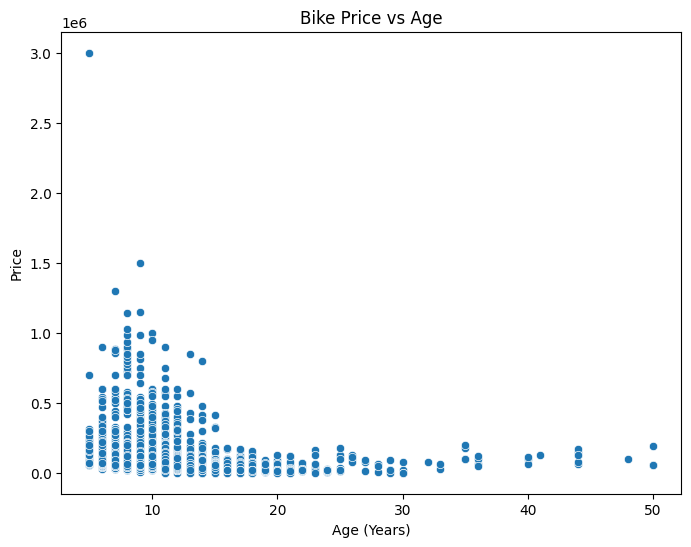

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=bikes_df, x='age', y='price')
plt.title('Bike Price vs Age')
plt.xlabel('Age (Years)')
plt.ylabel('Price')
plt.show()

In [13]:
# Filter bikes with Age = 10 and display Age and Price
bikes_df[bikes_df['age'] == 5][['age', 'price']]

,age,price
51,5,207500
102,5,150500
131,5,127500
132,5,73000
135,5,120000
...,...,...
4349,5,155600
4432,5,160000
4487,5,70000
4966,5,300000


In [14]:
# Filter 10-year-old bikes
bikes_5yr = bikes_df[bikes_df['age'] == 5]

# Get max price
max_price_5yr = bikes_10yr['price'].max()
print("Maximum Price among 5-year-old bikes:", max_price_5yr)

Maximum Price among 5-year-old bikes: 1000000


In [15]:
# Filter bikes with Price = 3,000,000 and get their Age
bikes_df[bikes_df['price'] == 3000000][['age', 'price']]

,age,price
2080,5,3000000


In [18]:
# Analyse price vs cc
bikes_df[['price', 'cc']].describe()

,price,cc
count,7.568000e+03,7344.000000
mean,9.808111e+04,244.678241
std,1.008627e+05,142.917997
min,0.000000e+00,97.000000
25%,4.400000e+04,150.000000
50%,7.500000e+04,200.000000
75%,1.250000e+05,350.000000
max,3.000000e+06,1750.000000


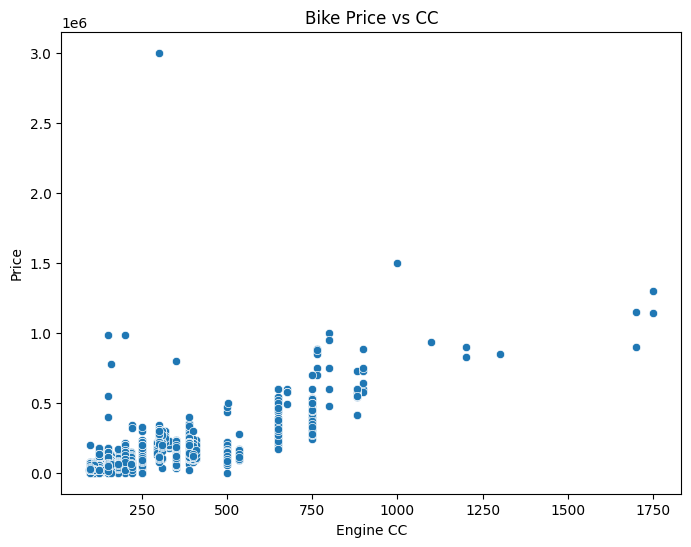

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(data=bikes_df, x='cc', y='price')
plt.title('Bike Price vs CC')
plt.xlabel('Engine CC')
plt.ylabel('Price')
plt.show()

In [20]:
# Analyse price and kms_driven
bikes_df[['price', 'kms_driven']].describe()

,price,kms_driven
count,7.568000e+03,7568.000000
mean,9.808111e+04,16569.866279
std,1.008627e+05,19408.900532
min,0.000000e+00,0.000000
25%,4.400000e+04,82.000000
50%,7.500000e+04,11000.000000
75%,1.250000e+05,24813.250000
max,3.000000e+06,190000.000000


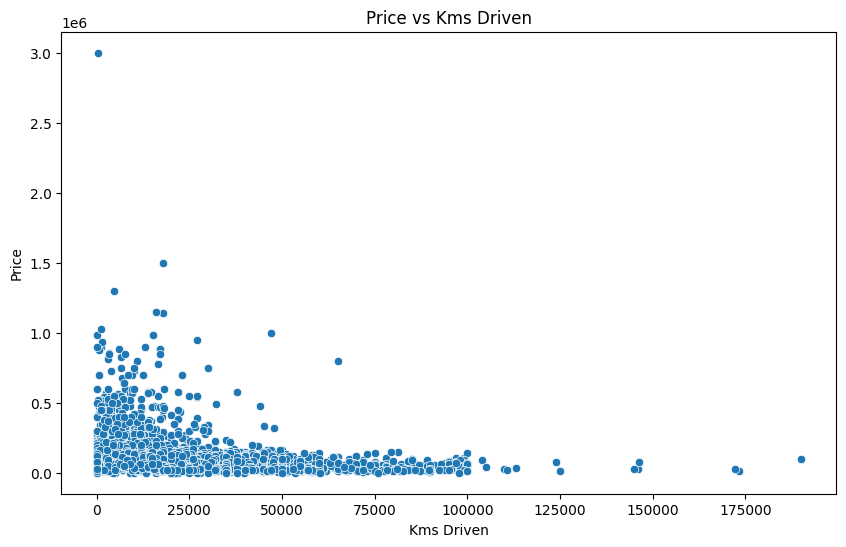

In [21]:
#plot
plt.figure(figsize=(10,6))
sns.scatterplot(x='kms_driven', y='price', data=bikes_df)
plt.title('Price vs Kms Driven')
plt.xlabel('Kms Driven')
plt.ylabel('Price')
plt.show()

In [23]:
bikes_df[['price', 'kms_driven']].corr()

,price,kms_driven
price,1.000000,-0.163695
kms_driven,-0.163695,1.000000


In [22]:
# lets analyse high dencity dots on the scatter plot 
bikes_df_filtered = bikes_df[(bikes_df['kms_driven'] < 50000) & (bikes_df['price'] < 2000000)]

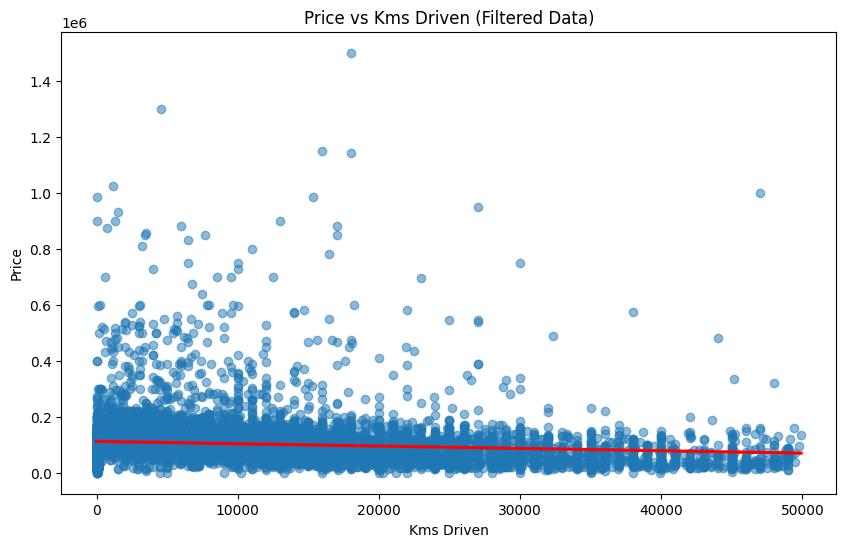

In [24]:
plt.figure(figsize=(10,6))

# Scatter plot with regression line on filtered data
sns.regplot(
    x='kms_driven', 
    y='price', 
    data=bikes_df_filtered, 
    scatter_kws={'alpha':0.5}, 
    line_kws={'color':'red'}
)

plt.title('Price vs Kms Driven (Filtered Data)')
plt.xlabel('Kms Driven')
plt.ylabel('Price')
plt.show()

**lets analyse Top Brands**

In [25]:
#Count of Bikes by Brand
bikes_df['brand'].value_counts().head(10)

brand
Bajaj Pulsar                  694
Royal Enfield Classic         598
TVS Apache RTR                430
Royal Enfield Thunderbird     415
Yamaha YZF-R                  302
KTM Duke                      265
KTM RC                        221
Bajaj Discover                218
Bajaj Pulsar RS               201
Bajaj Avenger Street          188
Name: count, dtype: int64

In [26]:
#Average Price by Brand
bikes_df.groupby('brand')['price'].mean().sort_values(ascending=False).head(10)

brand
BMW S                         1500000.0
Harley-Davidson Low Rider     1220625.0
Triumph Thunderbird Storm     1025000.0
Honda CB                       935000.0
Ducati Scrambler               932712.0
Harley-Davidson Roadster       917500.0
Aprilia RSV                    900000.0
Triumph Bonneville Bobber      865000.0
Honda VT                       850000.0
Triumph Tiger                  825000.0
Name: price, dtype: float64

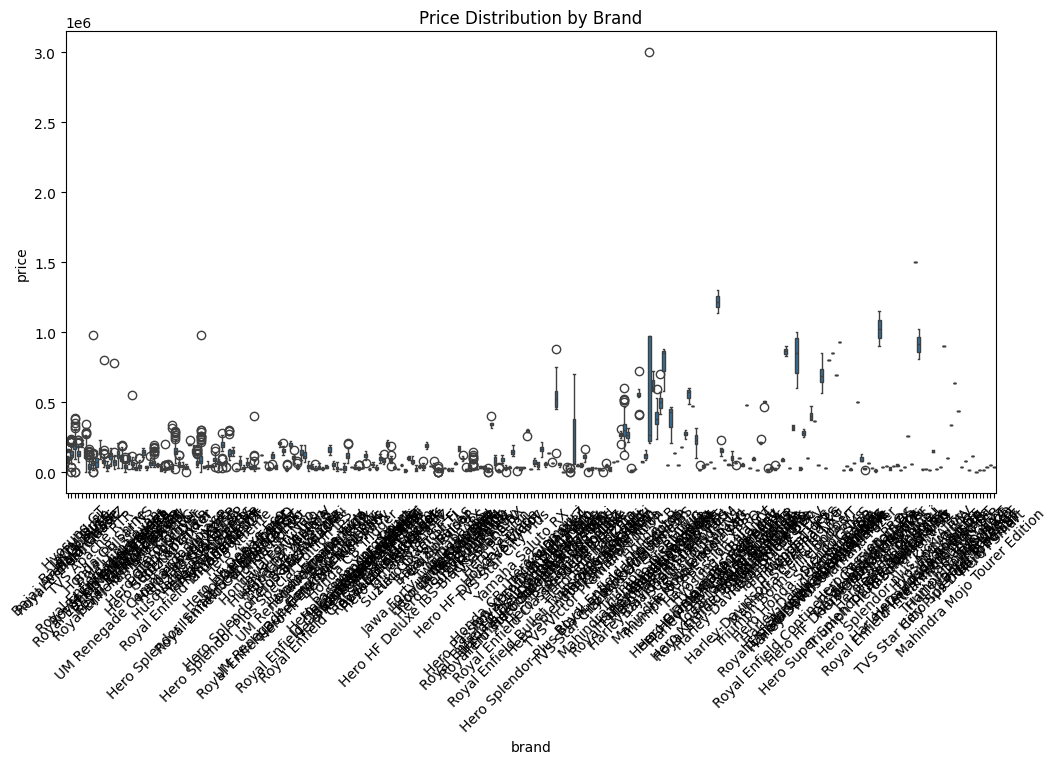

In [27]:
#visualize Brand vs Price
plt.figure(figsize=(12,6))
sns.boxplot(x='brand', y='price', data=bikes_df)
plt.xticks(rotation=45)
plt.title('Price Distribution by Brand')
plt.show()

In [28]:
# lets plot top 10 brands
top_brands = bikes_df['brand'].value_counts().head(10).index

top_brand_df = bikes_df[bikes_df['brand'].isin(top_brands)]

In [30]:
top_brand_df.head(10)

,model_name,model_year,kms_driven,owner,location,mileage_kmpl,power_bhp,price,cc,brand,age,power_cc_ratio,Age_group
1,Royal Enfield Classic 350cc 2016,2016,50000,first owner,Hyderabad,35,19.80,115000,350.0,Royal Enfield Classic,10,0.056571,"(5, 10]"
5,KTM Duke 200cc 2012,2012,24561,third owner,Bangalore,35,25.00,63400,200.0,KTM Duke,14,0.125000,"(10, 20]"
6,Bajaj Pulsar 180cc 2016,2016,19718,first owner,Bangalore,65,17.00,55000,180.0,Bajaj Pulsar,10,0.094444,"(5, 10]"
7,TVS Apache RTR 200 4V Dual Channel ABS BS6 2020,2020,40,first owner,Hyderabad,40,20.21,120000,200.0,TVS Apache RTR,6,0.101050,"(5, 10]"
8,KTM Duke 390cc 2018,2018,1350,first owner,Jaipur,25,42.90,198000,390.0,KTM Duke,8,0.110000,"(5, 10]"
10,Royal Enfield Classic 350cc 2018,2018,25000,first owner,Chennai,35,19.80,136900,350.0,Royal Enfield Classic,8,0.056571,"(5, 10]"
16,Royal Enfield Classic 350cc 2019,2019,12634,first owner,Delhi,35,19.80,160000,350.0,Royal Enfield Classic,7,0.056571,"(5, 10]"
19,Royal Enfield Thunderbird 350cc ABS 2019,2019,28000,first owner,Delhi,40,19.80,131500,350.0,Royal Enfield Thunderbird,7,0.056571,"(5, 10]"
22,Bajaj Pulsar 150cc 2014,2014,65,first owner,Delhi,65,14.85,47000,150.0,Bajaj Pulsar,12,0.099000,"(10, 20]"
23,Bajaj Avenger Street 220 2016,2016,9551,first owner,Delhi,53,19.00,52000,220.0,Bajaj Avenger Street,10,0.086364,"(5, 10]"


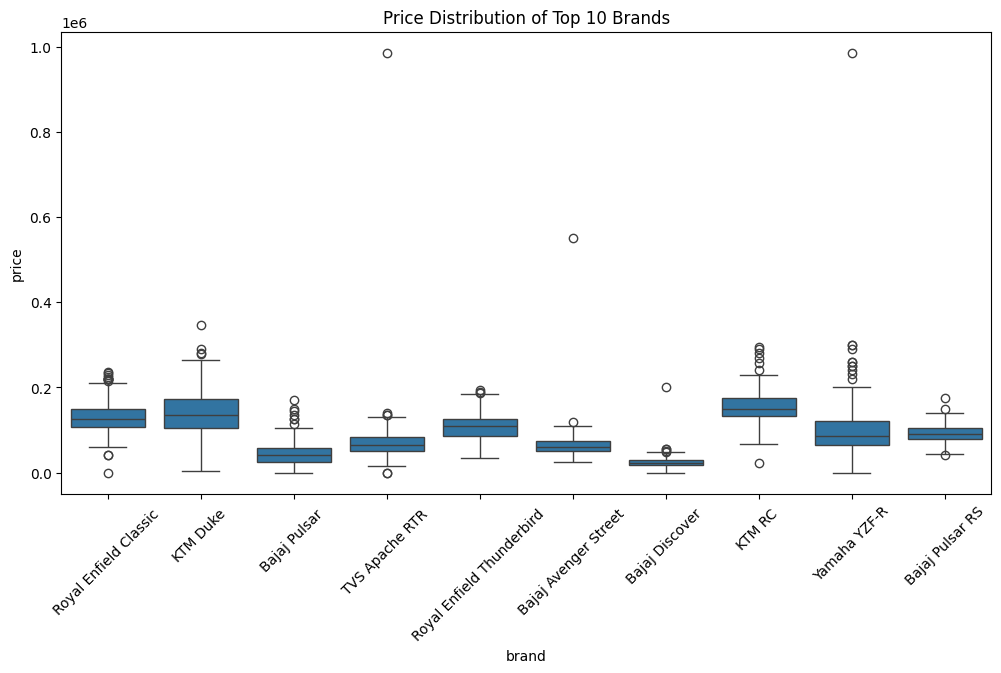

In [31]:
#plot top 10 brands
plt.figure(figsize=(12,6))
sns.boxplot(x='brand', y='price', data=top_brand_df)

plt.xticks(rotation=45)
plt.title('Price Distribution of Top 10 Brands')
plt.show()

**Descriptive Statistics**

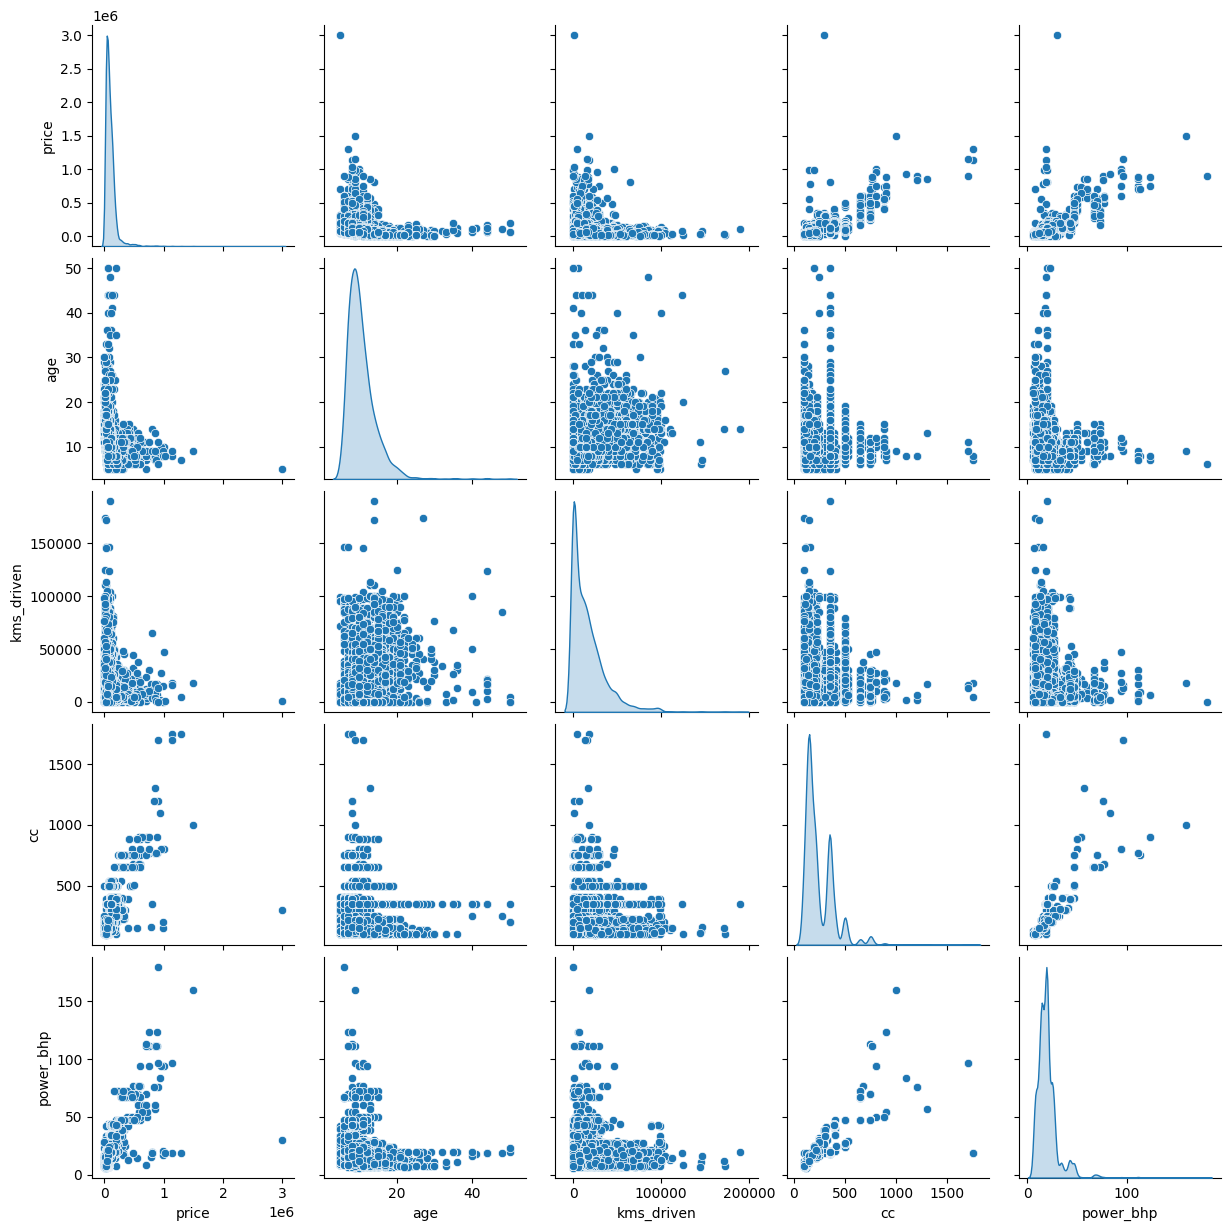

In [13]:
#1. Get a statistical summary of each numerical column (price, kms_driven, mileage, power, etc.)
pair_plot = sns.pairplot(
    bikes_df,
    vars=['price','age','kms_driven','cc','power_bhp'],
    diag_kind='kde'
)

# Save as PNG image
pair_plot.savefig("price_distribution", dpi=300)

plt.show()

In [35]:
 #2. Analyze the frequency distribution of categorical features such as model_year, owner, and brand
bikes_df['model_year'].value_counts().sort_index()

model_year
1950       2
1970       1
1978       1
1982       7
1985       1
1986       3
1990       4
1991       4
1993       2
1994       1
1996       4
1997       5
1998       4
1999       3
2000       6
2001      10
2002       8
2003      10
2004      27
2005      43
2006      62
2007      74
2008      91
2009     148
2010     191
2011     250
2012     323
2013     417
2014     589
2015     757
2016     984
2017    1127
2018    1073
2019     872
2020     373
2021      91
Name: count, dtype: int64

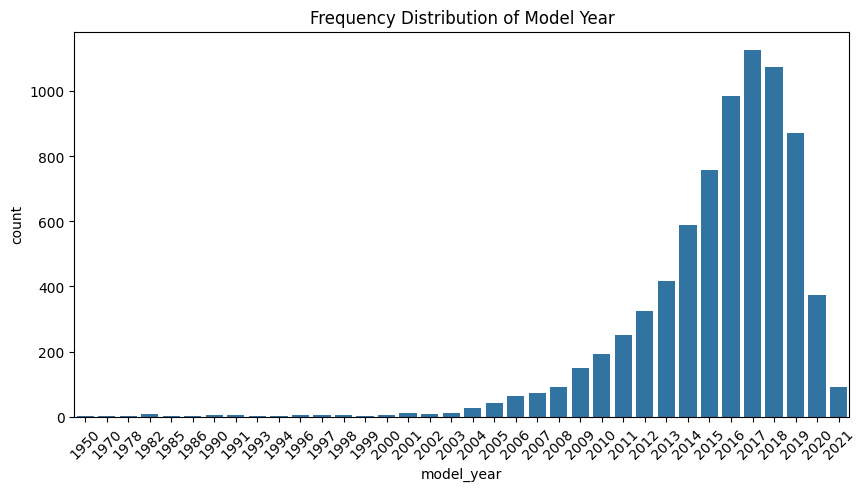

In [36]:
# plot freequency distribution by model year
plt.figure(figsize=(10,5))
sns.countplot(x='model_year', data=bikes_df)

plt.xticks(rotation=45)
plt.title("Frequency Distribution of Model Year")
plt.show()

In [37]:
#Frequency Distribution – Owner
bikes_df['owner'].value_counts()

owner
first owner             6564
second owner             801
third owner              132
fourth owner or more      71
Name: count, dtype: int64

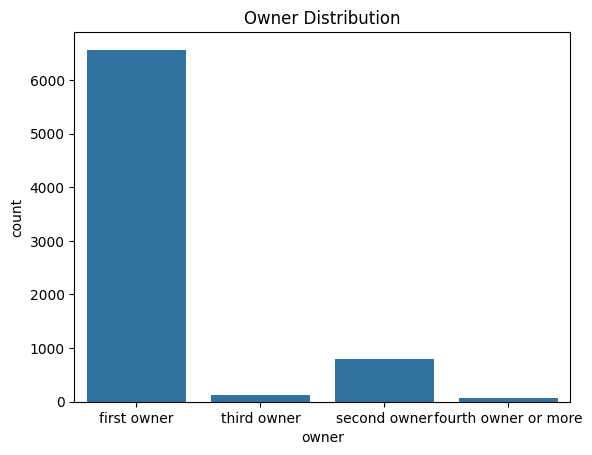

In [38]:
sns.countplot(x='owner', data=bikes_df)

plt.title("Owner Distribution")
plt.show()

In [42]:
#3.Frequency Distribution – Brand (top 10 brands)
bikes_df['brand'].value_counts()

brand
Bajaj Pulsar                  694
Royal Enfield Classic         598
TVS Apache RTR                430
Royal Enfield Thunderbird     415
Yamaha YZF-R                  302
                             ... 
BMW S                           1
Yazdi Road King                 1
Honda CD                        1
Bajaj Pulsar                    1
Hero i Smart                    1
Name: count, Length: 259, dtype: int64

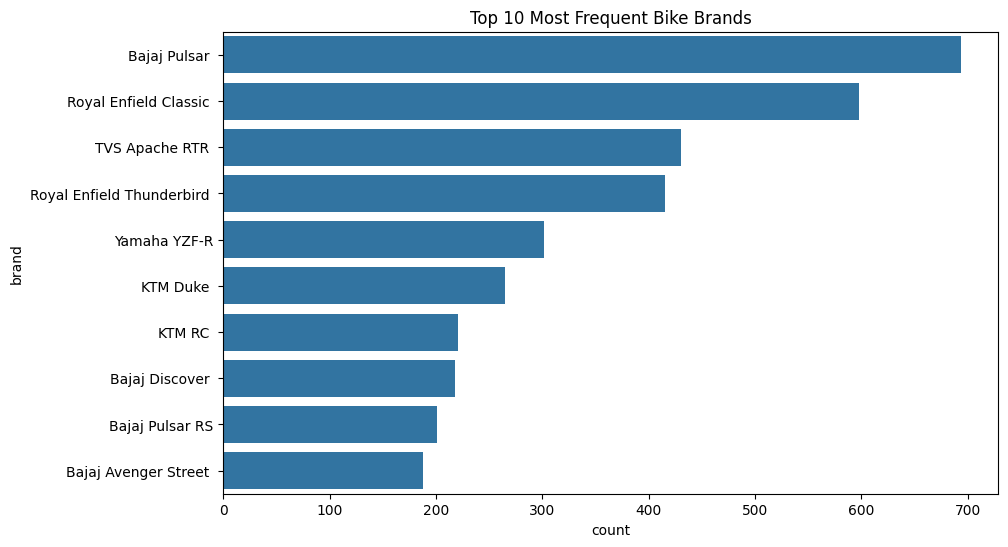

In [44]:
top_brands = bikes_df['brand'].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.countplot(
    y='brand',
    data=bikes_df[bikes_df['brand'].isin(top_brands)],
    order=top_brands
)

plt.title("Top 10 Most Frequent Bike Brands")
plt.show()

** Bivarient Analysis**

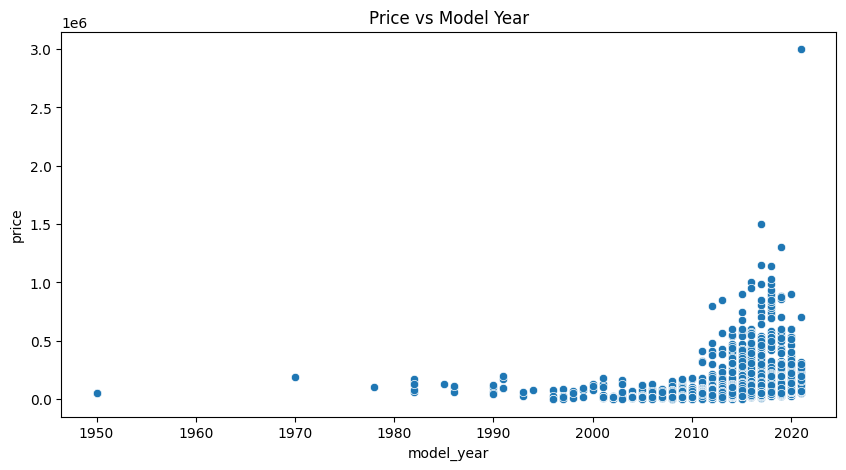

In [14]:
#Price vs Model Year
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.scatterplot(x='model_year', y='price', data=bikes_df)

plt.title("Price vs Model Year")

plt.show()

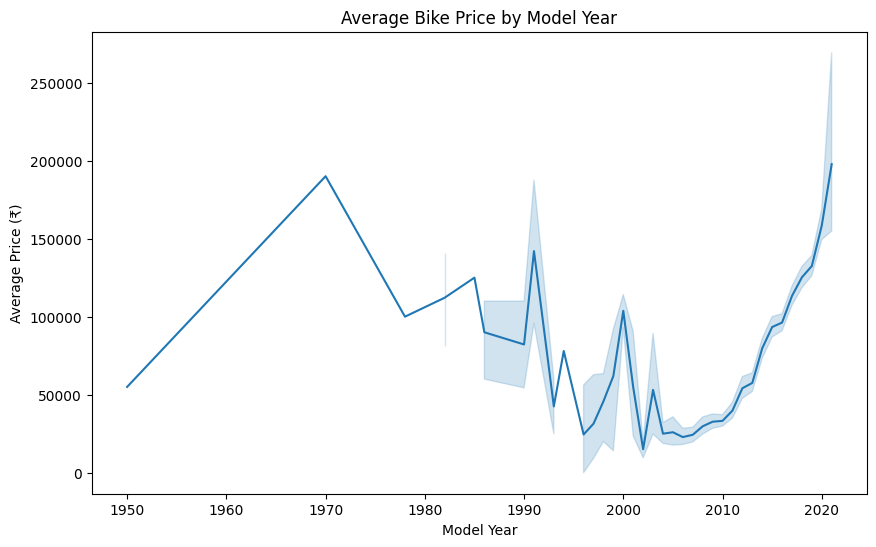

In [16]:

plt.figure(figsize=(10,6))

sns.lineplot(x='model_year', y='price', data=bikes_df, estimator='mean')

plt.title('Average Bike Price by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Average Price (₹)')

plt.savefig("avg_price_by_model_year.png", dpi=300, bbox_inches='tight')

plt.show()

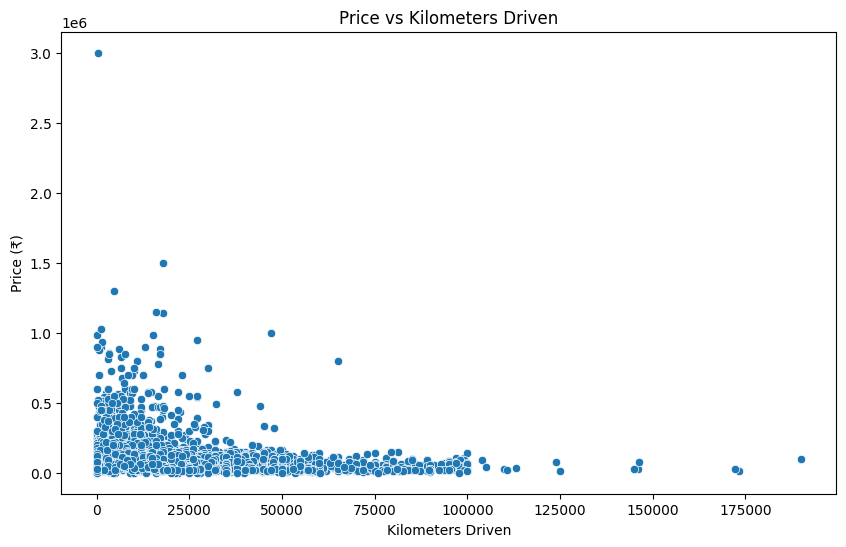

In [17]:

plt.figure(figsize=(10,6))

sns.scatterplot(x='kms_driven', y='price', data=bikes_df)

plt.title('Price vs Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price (₹)')

plt.savefig("price_vs_kms_driven.png", dpi=300, bbox_inches='tight')

plt.show()

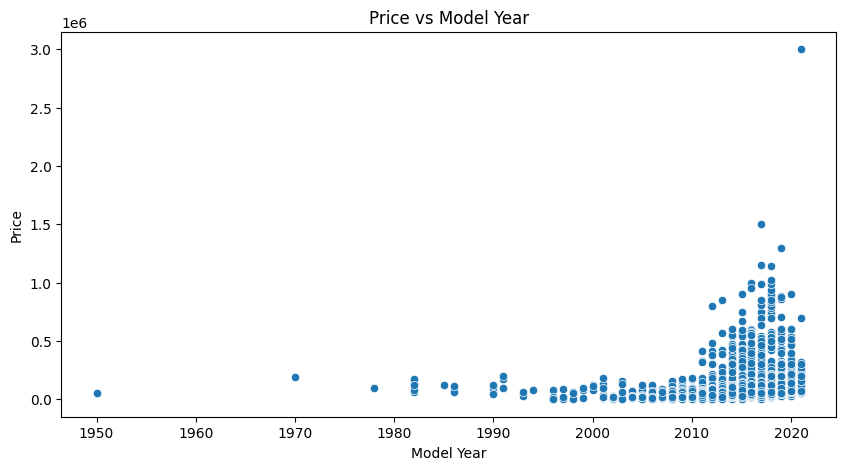

In [48]:
#price vs model_year
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.scatterplot(x='model_year', y='price', data=bikes_df)

plt.title("Price vs Model Year")
plt.xlabel("Model Year")
plt.ylabel("Price")

plt.show()

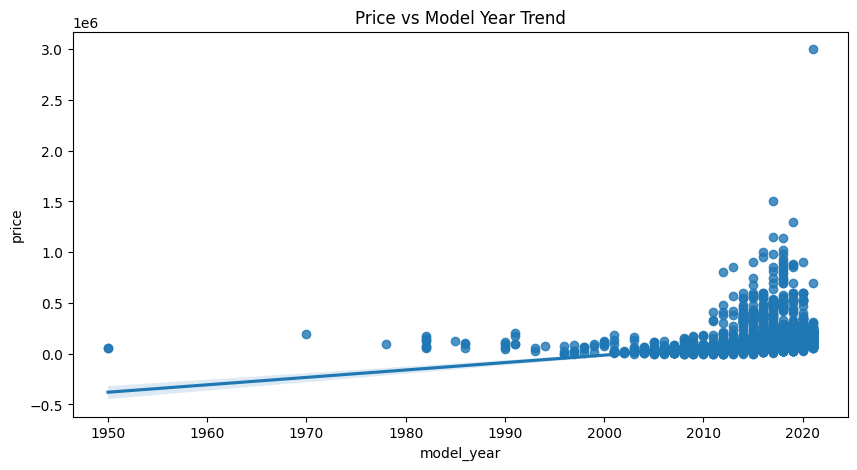

In [49]:
plt.figure(figsize=(10,5))

sns.regplot(x='model_year', y='price', data=bikes_df)

plt.title("Price vs Model Year Trend")

plt.show()

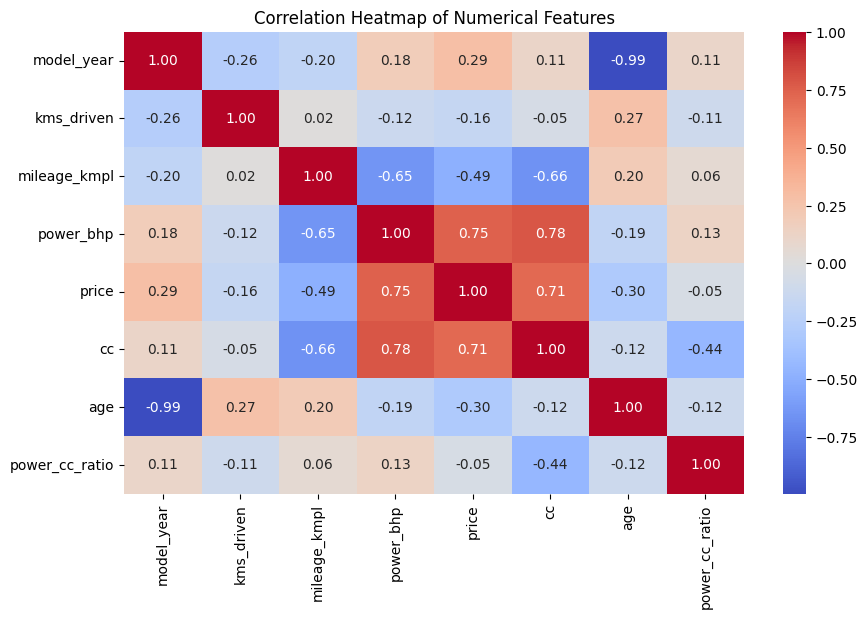

In [50]:
#2.correlation heatmap of numerical features 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

corr_matrix = bikes_df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

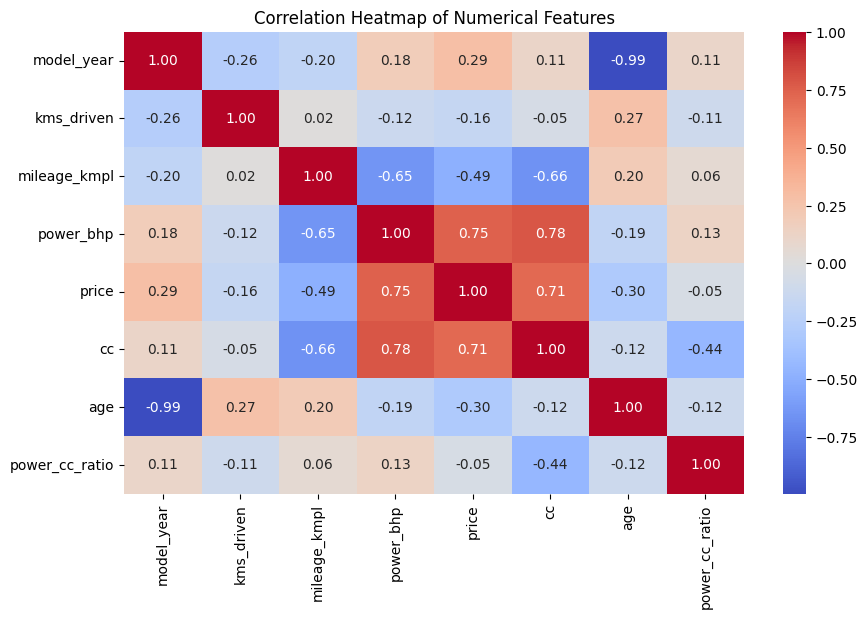

In [18]:

plt.figure(figsize=(10,6))

corr_matrix = bikes_df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Numerical Features")

# Save heatmap as PNG
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

**End of EDA Analysis of resalable bikes**

In [1]:
#year wise split of bikes
bikes_df

NameError: name 'bikes_df' is not defined

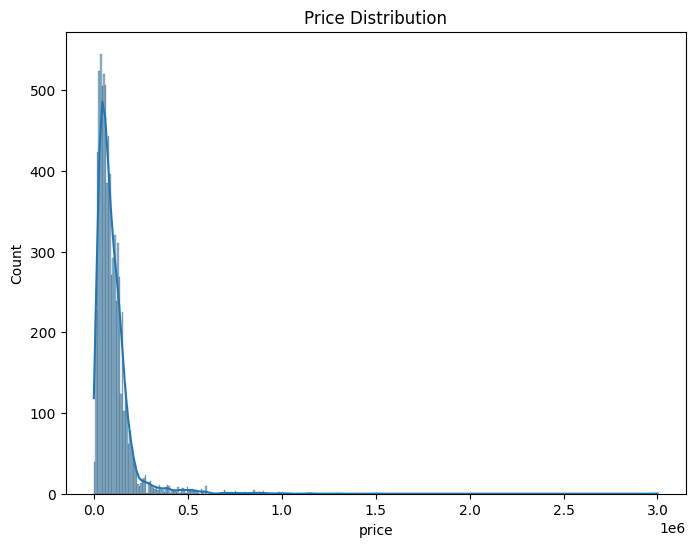

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
books_df = pd.read_csv("used_bikes_price_analysis_dataset.csv")
# Price Distribution
plt.figure(figsize=(8,6))
sns.histplot(bikes_df['price'], kde=True)
plt.title('Price Distribution')
plt.show()


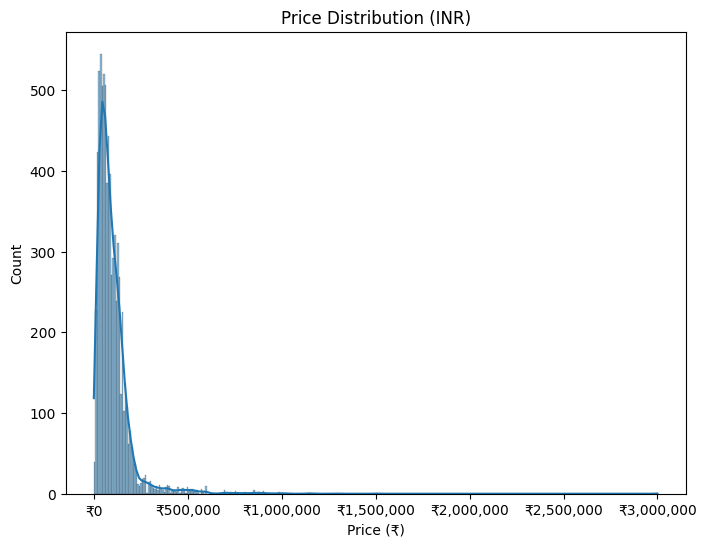

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

bikes_df = pd.read_csv("used_bikes_price_analysis_dataset.csv")

plt.figure(figsize=(8,6))

sns.histplot(bikes_df['price'], kde=True)

# Format x-axis to Indian Rupees
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'₹{int(x):,}'))

plt.title('Price Distribution (INR)')
plt.xlabel('Price (₹)')
plt.ylabel('Count')

plt.show()